In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.power_law_fitting import PowerLawFitting
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = PowerLawFitting(dp, LAD_min=0,
            sensitivity_model = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg))

In [3]:
from statsmodels.base.model import GenericLikelihoodModelResults

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = PowerLawFitParams(q=1.63, g=1.8),
    verbose = False,
    summary = True
)

C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\power_law_fitting.py:46: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -2.5609e+06
Model:                      TheoryFit   AIC:                         5.122e+06
Method:            Maximum Likelihood   BIC:                         5.122e+06
Date:                Fri, 03 Jul 2026                                         
Time:                        13:09:39                                         
No. Observations:              412506                                         
Df Residuals:                  412504                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           0.8476        nan        nan        nan         nan         nan
par1           2.2770        nan        nan        n

C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\power_law_fitting.py:46: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)


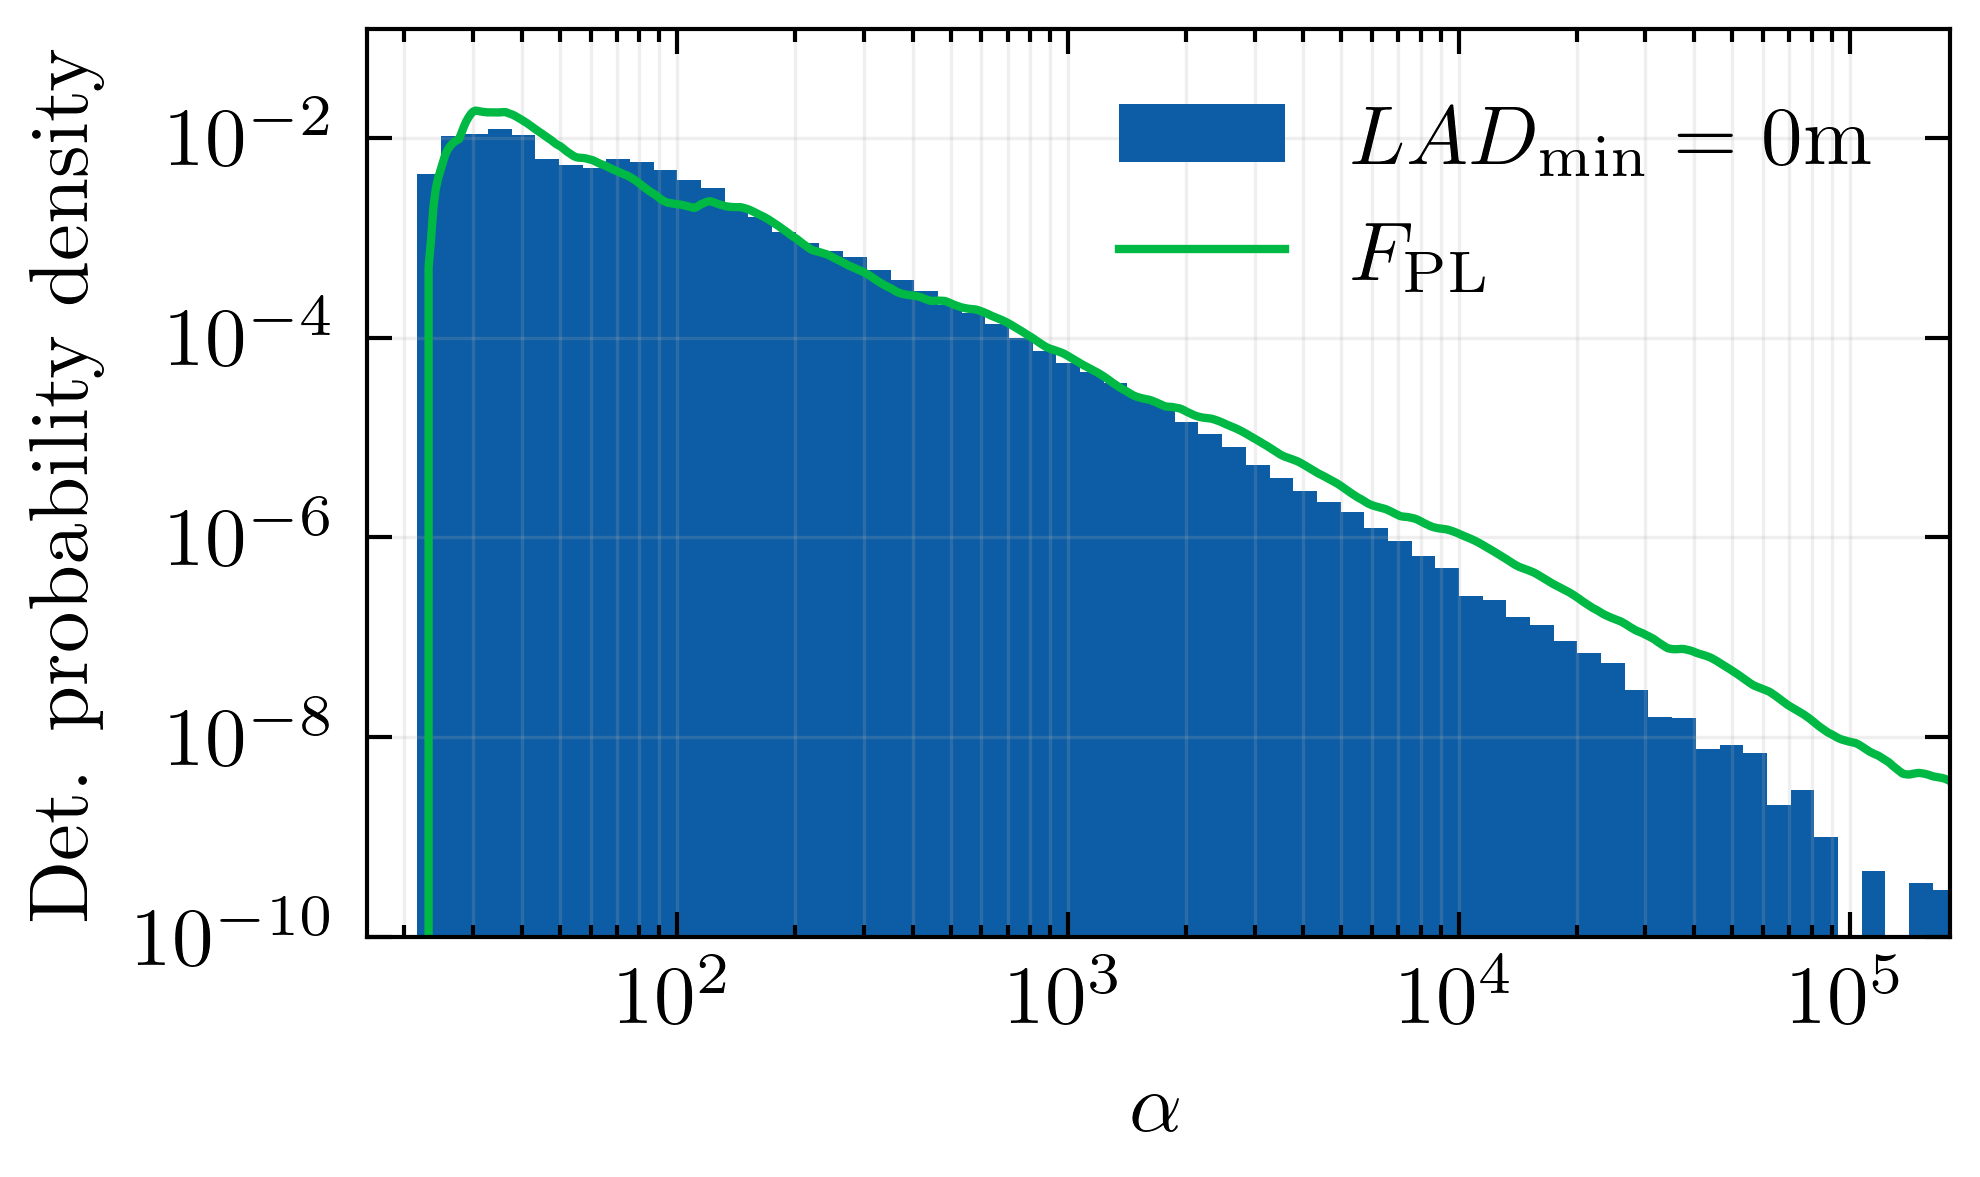

In [4]:
# 1.6290 0.6006 for LAD min = 2
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_alphas_best_S,
                           alphas_hist, density = True, label = rf"$LAD_{{\text{{min}}}} = {fit.LAD_min}$m")

fit_params = PowerLawFitParams(*mle_model.params)
# fit_params = PowerLawFitParams(q=2, g=100)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_S_function), label = r"$F_{\text{PL}}$")

plt.ylim(1e-10, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
# plt.savefig(f".plots/PL_fit_LAS_gt_{fit.LAD_min}m.png")
plt.show()

In [ ]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/PowerLaw")

while True:
    df = fit.MultiMLEFit(
        optimize_params=PowerLawFitParams(q=1.63, g=1.8),
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"
    filename.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\src\boulder_statistics\analysis\power_law_fitting.py:46: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
